In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.metrics import sensitivity_specificity_support
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ganjar87/data_science_practice/refs/heads/main/healthcare-dataset-stroke-data.csv')

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


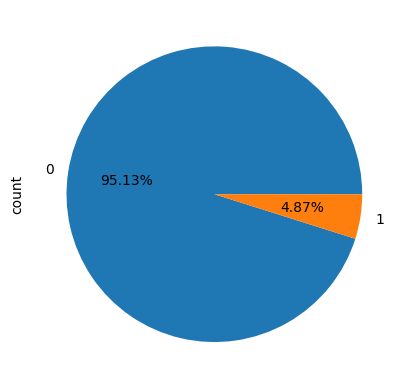

In [6]:
data = df['stroke'].value_counts()
data.plot(kind='pie', autopct='%.2f%%')
plt.show()

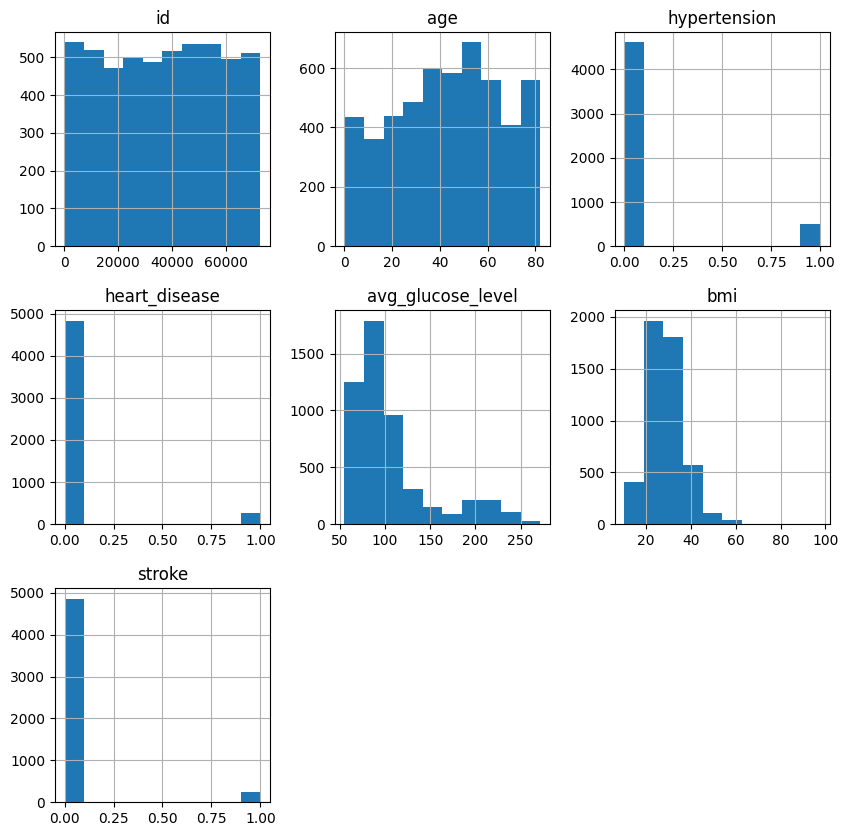

In [7]:
df.hist(figsize=(10, 10))
plt.show()

In [8]:
print('Cek Missing value')
print()
df.isnull().sum()

Cek Missing value



,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [9]:
df_X = df.drop(['id', 'stroke'], axis=1)
# mendefinisikan kolom yang jadi input
df_y = df[['stroke']]
# mendefinisikan kolom yang jadi output
cats = df_X.select_dtypes(include=['object', 'bool']).columns
print(cats)

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


**Data Preprocessing**

In [10]:
# memulai data preprocessing
# membuat X dan y. X untuk input variable, y untuk target class
df_X = df.drop(['id', 'stroke'],axis=1)
df_y = df[['stroke']]

# label encoding for y.
# merubah nilai yg ada di y menjadi 0 atau 1
# sebenernya tdk diperlukan karena nilai y di dataset sudah 0 atau 1
le = LabelEncoder()
df_y = le.fit_transform(df_y['stroke'])

# imputation
df_X['bmi'].fillna(df_X['bmi'].median(), inplace=True)

# categorical encoding
# merubah categorical value menjadi numerical value
# bisa pakai label encoding, ordinal atau one hot encoding
cats = df_X.select_dtypes(include=['object', 'bool']).columns
cat_features = list(cats.values)
le = LabelEncoder()
for i in cat_features:
  df_X[i] = le.fit_transform(df_X[i])

# menyimpan X dan y menjadi numpy arrays
X = df_X.astype(float).values
y = df_y.astype(float)

# hold-out method
# dibagi menjadi training dan testing set
# 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# scaling
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

/tmp/ipykernel_1687/1443321232.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_X['bmi'].fillna(df_X['bmi'].median(), inplace=True)


In [11]:
X

array([[  1.  ,  67.  ,   0.  , ..., 228.69,  36.6 ,   1.  ],
       [  0.  ,  61.  ,   0.  , ..., 202.21,  28.1 ,   2.  ],
       [  1.  ,  80.  ,   0.  , ..., 105.92,  32.5 ,   2.  ],
       ...,
       [  0.  ,  35.  ,   0.  , ...,  82.99,  30.6 ,   2.  ],
       [  1.  ,  51.  ,   0.  , ..., 166.29,  25.6 ,   1.  ],
       [  0.  ,  44.  ,   0.  , ...,  85.28,  26.2 ,   0.  ]])

In [12]:
y

array([1., 1., 1., ..., 0., 0., 0.])

In [13]:
X_train

array([[ 1.18418048, -1.7467638 , -0.31719928, ..., -0.340693  ,
        -1.64591683, -1.29622579],
       [ 1.18418048, -0.63635252, -0.31719928, ...,  2.26654137,
        -0.78843307,  1.52066342],
       [ 1.18418048,  0.02989425,  3.15259225, ..., -0.32155489,
        -0.30772248,  0.58170035],
       ...,
       [-0.84446587, -1.87290652, -0.31719928, ..., -0.18803315,
        -1.43804198, -1.29622579],
       [ 1.18418048,  1.62888649, -0.31719928, ...,  2.01062472,
         0.27692553, -0.35726272],
       [-0.84446587,  0.11872715, -0.31719928, ..., -0.12416526,
         2.78441591,  1.52066342]])

In [14]:
X_test

array([[ 1.18418048, -0.54751962, -0.31719928, ..., -0.90971812,
        -0.76244872, -1.29622579],
       [ 1.18418048, -0.14777156, -0.31719928, ..., -0.89992653,
        -0.07386327,  0.58170035],
       [-0.84446587, -1.569098  , -0.31719928, ..., -0.69675096,
        -0.82740961, -1.29622579],
       ...,
       [ 1.18418048, -0.05893866, -0.31719928, ..., -0.26569829,
        -0.21677723,  0.58170035],
       [-0.84446587,  0.60730811, -0.31719928, ..., -0.80846414,
        -0.63252693, -1.29622579],
       [-0.84446587,  0.74055746, -0.31719928, ..., -0.72746095,
        -0.46362862,  0.58170035]])

**Modeling**

Accuracy  0.9419439008480104
Precision  0.4709719504240052
Recall  0.5
Confusion Matrix  [[1444    0]
 [  89    0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


F1  0.485052065838092


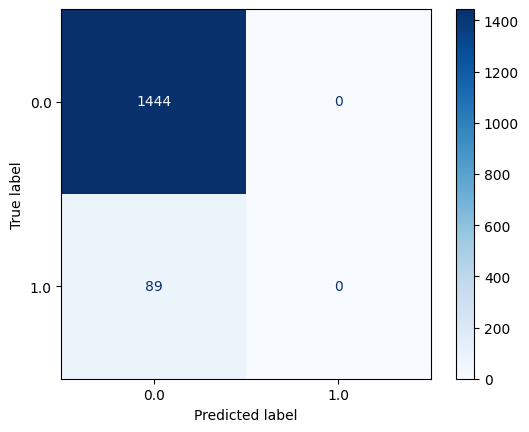

In [15]:
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# y_pred jika di printout akan keluar vektor prediksi nya
# menghitung performa model dengan accuracy, dll
print('Accuracy ', accuracy_score(y_test, y_pred))
print('Precision ', precision_score(y_test, y_pred, average='macro'))
print('Recall ', recall_score(y_test, y_pred, average='macro'))
print('Confusion Matrix ', confusion_matrix(y_test, y_pred))

# plot_confusion_matrix(model, X_test, y_test, cmap=plt.cm.blues)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

# plt.show()
disp.plot(cmap=plt.cm.Blues)

print('F1 ', f1_score(y_test, y_pred, average='macro'))



In [16]:
print('Model coefficient')
model.coef_

Model coefficient


array([[-0.01878829,  1.55249921,  0.10370412,  0.07921647, -0.18371621,
        -0.06959651,  0.06033662,  0.19742689, -0.03156246,  0.02218138]])

In [17]:
print('Model Intercept')
model.intercept_

Model Intercept


array([-4.04531553])

**KNN**

Accuracy  0.9419439008480104
Precision  0.4709719504240052
Recall  0.5
Confusion Matrix  [[1444    0]
 [  89    0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


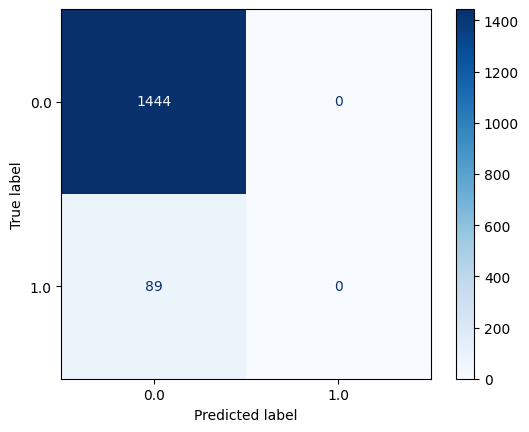

In [18]:
model=KNeighborsClassifier(n_neighbors=10)
model.fit(X_train, y_train)

# membuat prediksi
y_pred = model.predict(X_test)

# menghitung performa model, dengan accuracy dll
print('Accuracy ', accuracy_score(y_test, y_pred))
print('Precision ', precision_score(y_test, y_pred, average='macro'))
print('Recall ', recall_score(y_test, y_pred, average='macro'))
print('Confusion Matrix ', confusion_matrix(y_test, y_pred))

# plot_confusion_matrix(model, X_test, y_test, cmap=plt.cm.Blues)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))


# plt.show()
disp.plot(cmap=plt.cm.Blues)

**Decision Tree**

Accuracy  0.9054142204827136
Precision  0.5386789726546979
Recall  0.533326589685331
Confusion matrix  [[1378   66]
 [  79   10]]


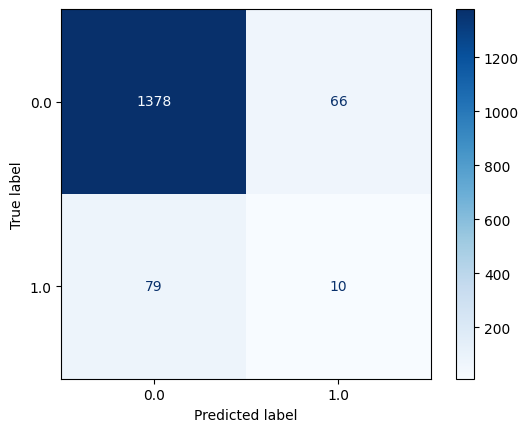

In [19]:
model=DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

# membuat prediksi
y_pred = model.predict(X_test)

# menghitung performa model dengan accuracy dll
print('Accuracy ', accuracy_score(y_test, y_pred))
print('Precision ', precision_score(y_test, y_pred, average='macro'))
print('Recall ', recall_score(y_test, y_pred, average='macro'))
print('Confusion matrix ', confusion_matrix(y_test, y_pred))

# plot_confusion_matrix(model, X_test, y_test, cmap=plt.cm.Blues)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))


# plt.show()
disp.plot(cmap=plt.cm.Blues)

**Random Forest**

Accuracy  0.9412915851272016
Precision  0.6379084967320261
Recall  0.5049254567524666
Confusion matrix  [[1442    2]
 [  88    1]]


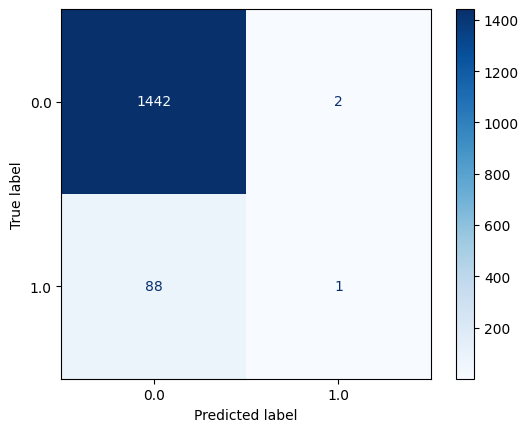

In [20]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

# membuat prediksi
y_pred = model.predict(X_test)

# menghitung performa model, dengan accuracy dll
print('Accuracy ', accuracy_score(y_test, y_pred))
print('Precision ', precision_score(y_test, y_pred, average='macro'))
print('Recall ', recall_score(y_test, y_pred, average='macro'))
print('Confusion matrix ', confusion_matrix(y_test, y_pred))

# plot_confusion_matrix(model, X_train, y_test, cmap=plt.cm.Blues)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))


# plt.show()
disp.plot(cmap=plt.cm.Blues)

**AdaBoost**

Accuracy  0.9419439008480104
Precision  0.4709719504240052
Recall  0.5
Confusion matrix  [[1444    0]
 [  89    0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


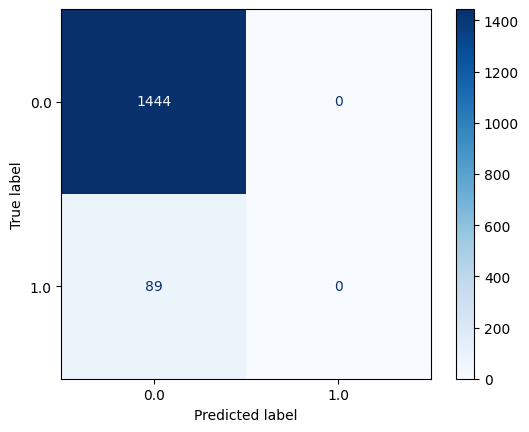

In [21]:
model=AdaBoostClassifier()
model.fit(X_train, y_train)

# membuat prediksi
y_pred = model.predict(X_test)

# menghitung performa model, dengan accuracy
print('Accuracy ', accuracy_score(y_test, y_pred))
print('Precision ', precision_score(y_test, y_pred, average='macro'))
print('Recall ', recall_score(y_test, y_pred, average='macro'))
print('Confusion matrix ', confusion_matrix(y_test, y_pred))

# plot_confusion_matrix(model, X_train, y_test, cmap=plt.cm.Blues)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))


# plt.show()
disp.plot(cmap=plt.cm.Blues)

# **Tugas & Analisis**

In [22]:
import pandas as pd
import numpy as np

In [23]:
url = "https://raw.githubusercontent.com/matthewpriantara/Data_Mining_Practice/main/pert_3/loan_data.csv"
df = pd.read_csv(url)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [24]:
print('Melihat Ukuran Dataset nya')
df.shape

Melihat Ukuran Dataset nya


(381, 13)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [26]:
print('Melihat seluruh kolom')
df.columns

Melihat seluruh kolom


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

**Untuk input output nya:**

X = input / features
y = output / target

In [27]:
print('Cek Missing value dulu dong')
df.isnull().sum()

Cek Missing value dulu dong


,0
Loan_ID,0
Gender,5
Married,0
Dependents,8
Education,0
Self_Employed,21
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,11


In [28]:
print('Cek persentase nya')
(df.isnull().sum() / len(df) * 100).round(2)

Cek persentase nya


,0
Loan_ID,0.00
Gender,1.31
Married,0.00
Dependents,2.10
Education,0.00
Self_Employed,5.51
ApplicantIncome,0.00
CoapplicantIncome,0.00
LoanAmount,0.00
Loan_Amount_Term,2.89


In [29]:
print('Cek data duplikat')
df.duplicated().sum()

Cek data duplikat


np.int64(0)

**Cek Target**

In [30]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,271
N,110


In [31]:
df["Loan_Status"].value_counts(normalize=True) * 100

,proportion
Loan_Status,
Y,71.128609
N,28.871391


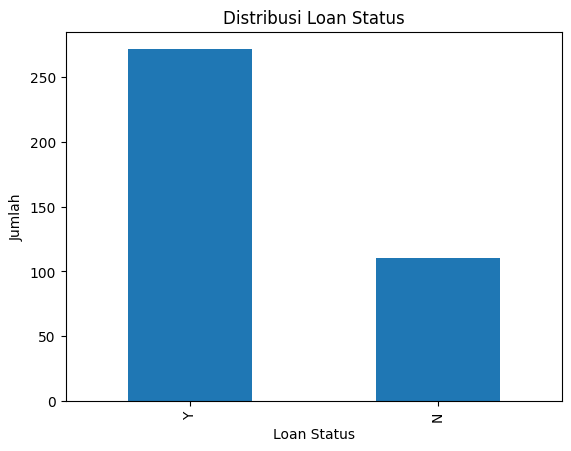

In [32]:
import matplotlib.pyplot as plt

df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Distribusi Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Jumlah")
plt.show()

**MEnangani Missing Value nya**

In [33]:
print('Memisahkan X dan y')
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

Memisahkan X dan y


In [34]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
4,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban


In [35]:
y.head()

,Loan_Status
0,N
1,Y
2,Y
3,Y
4,Y


**Train Test Split**

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, # untuk pembagian data konsisten
    stratify=y # untuk menjaga proporsi Y dan N agar relatif sama antara training dan testing
)

**80% => training**

**20% => testing**

**Preprocessing dengan Pipeline**

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [61]:
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

In [62]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [63]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Model 1 (Logistic Regression)**

In [52]:
from sklearn.linear_model import LogisticRegression

In [65]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [66]:
# Training
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [67]:
# Prediksi
y_pred_lr = logistic_model.predict(X_test)

**MOdel - KNN**

In [68]:
from sklearn.neighbors import KNeighborsClassifier

In [69]:
# Pipeline
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]
)

In [70]:
# Training
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('classifier', KNeighborsClassifier())])

In [71]:
# Prediksi
y_pred_knn = knn_model.predict(X_test)

**Model - Decision Tree**

In [72]:
from sklearn.tree import DecisionTreeClassifier

In [73]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [74]:
# Training
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [75]:
# Prediksi
y_pred_dt = decision_tree_model.predict(X_test)

**Model - Random Forest**

In [76]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [77]:
# Training
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [78]:
# prediksi
y_pred_rf = random_forest_model.predict(X_test)

# ***Evaluasi Model***

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [85]:
result = []

models = {
    "Logistic Regression" : y_pred_lr,
    "KNN" : y_pred_knn,
    "Decision Tree" : y_pred_dt,
    "Random Forest" : y_pred_rf
}

for model_name, predictions in models.items():
  result.append({
      "Model" : model_name,
      "Accuracy": accuracy_score(y_test, predictions),
      "Precision": precision_score(y_test, predictions, pos_label="Y"),
      "Recall": recall_score(y_test, predictions, pos_label="Y")
  })

results_df = pd.DataFrame(result)
results_df

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.857143,0.833333,1.000000
1,KNN,0.844156,0.841270,0.963636
2,Decision Tree,0.792208,0.854545,0.854545
3,Random Forest,0.883117,0.859375,1.000000


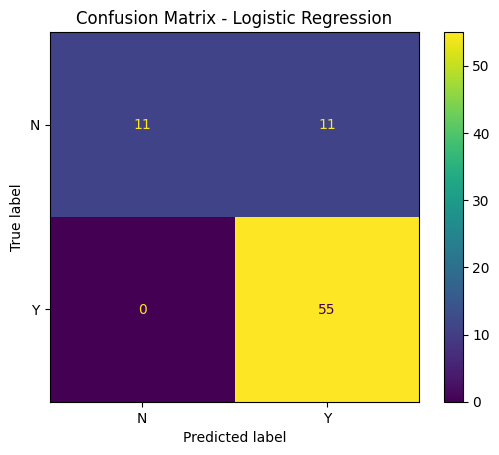

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

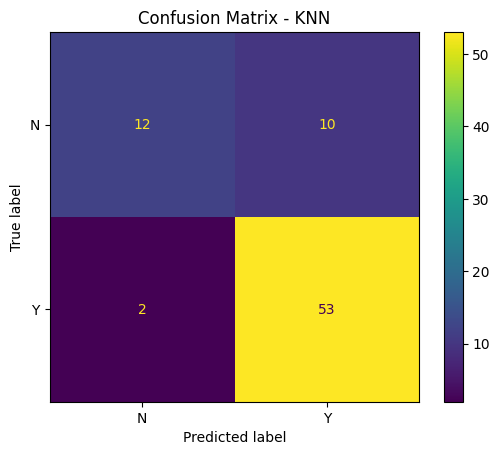

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn
)

plt.title("Confusion Matrix - KNN")
plt.show()

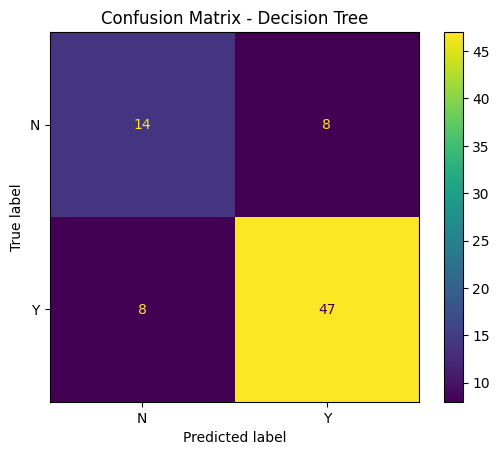

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt
)

plt.title("Confusion Matrix - Decision Tree")
plt.show()

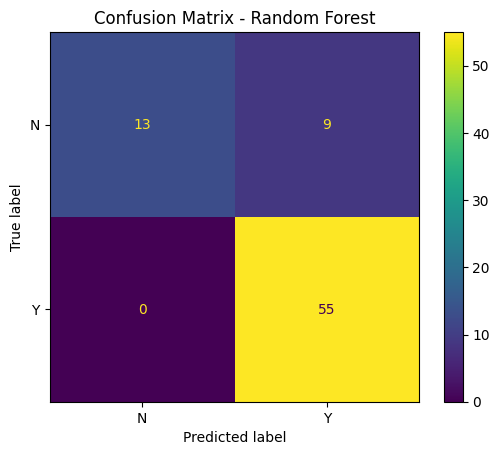

In [92]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [93]:
from sklearn.metrics import confusion_matrix

for model_name, predictions in models.items():
    cm = confusion_matrix(y_test, predictions, labels=["N", "Y"])

    print(f"\n{model_name}")
    print(cm)


Logistic Regression
[[11 11]
 [ 0 55]]

KNN
[[12 10]
 [ 2 53]]

Decision Tree
[[14  8]
 [ 8 47]]

Random Forest
[[13  9]
 [ 0 55]]
